# Laboratorio 1: Regresión Lineal Múltiple — Predicción de Tasa de Interés
**Autor:** Valencia Medina Freddy D.  
**Dataset:** [Lending Club — Accepted Loans 2007-2018 Q4](https://www.kaggle.com/wordsforthewise/lending-club)  
**Objetivo:** Predecir la tasa de interés (`int_rate`) que Lending Club asigna a un préstamo

1. ~2.2 millones de filas (n), 151 columnas (m)
2. ~2.1 millones filas (n), 51 columnas (m) tras limpieza
3. Separacion de filas con split train/test 80/20

In [1]:
#importamos numpy esta libreria nos permite manejar matrices
import numpy as np
#usamos pandas para poder ver nuestro dataset y prepararlo para poder luego trabajarlo 
#con numpy
import pandas as pd 

#importamos matplotlib y pyplot para poder  graficar y ver visualmetne 
import matplotlib
from matplotlib import pyplot

# importamos os que  nos permite poder leer rutas y manejo de archivos
import os
 
#Escáner de directorio: Busca e imprime la ruta exacta de los datasets cargados en Kaggle para poder copiarlos.
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


In [2]:
#ruta del dataset 
ruta_dataset = '/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz'
#usamos la funcion de pandas read_csv, usamos gzip porque el dataset esta comprimido
#low_memory = False es debido a la inconsistencia en los tipos de las columnas
df_raw = pd.read_csv(ruta_dataset, compression='gzip', low_memory=False)
#imprimimos el atributo shape de nuestro dataset para saber las filas y columnas
print('shape original: ', df_raw.shape)

shape original:  (2260701, 151)


## Exploración inicial — Análisis de valores nulos
Calculamos el **porcentaje de nulos por columna** con la fórmula:

$$\text{%\ nulos}_j = \frac{\sum_{i=1}^{m} \mathbb{1}[x_{ij} = \text{NaN}]}{m} \times 100$$

Esto nos permite decidir qué columnas conservar (< 30 % nulos), cuáles imputar y cuáles eliminar.

In [3]:
#extraemos solamente los encabezados de cada columna y usamos la funcion .tolist()
#esto nos permite  convertir el formato de Index  a una lista y la imprimimos
print(df_raw.columns.tolist())
#usadmos la funcion set_option para que nos muestre todas las filas y no las abrevie

pd.set_option('display.max_rows',None)

#usamos la funcion .isnull() para poder obtener todos los nulos y luego con .sum()
#obtenemos el numero total de nulos por columna esto lo dividimos entre el largo de toda la tabla
# es decir las filas  de esta  manera sacamos la proporcion de nulos en cada fila
# lo multiplicamos por 100 para poder obtener el porcentaje de nulso por columna
print(df_raw.isnull().sum() / len(df_raw)*100)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

## Manjeo de características

Transformamos columnas de texto en numéricas para que el modelo las procese:

| Columna original | Transformación | Resultado |
|---|---|---|
| `term` | `" 36 months"` → `36.0` | Numérica continua |
| `earliest_cr_line` | `"Jan-2005"` → años desde 2018-12-31 | `credit_history_years` (float) |
| `home_ownership` | One-hot encoding manual | `home_ownership_OWN`, `home_ownership_MORTGAGE` (binarias) |
| `verification_status` | One-hot encoding manual | `verification_status_Source Verified`, `verification_status_Verified` (binarias) |

> **Nota sobre variables dummy:** Para $k$ categorías se crean $k-1$ columnas binarias. La categoría omitida (RENT, Not Verified) queda representada cuando todas las dummies valen 0. Esto evita la multicolinealidad

In [4]:
# Copiamos el dataset para no modificar el original aunque ocupa el doble de memoria
# nos da un seguro en caso nos equivoquemos al limpiar datos
df = df_raw.copy()

# Convertir term (plazo) a float reemplazando el acompanamientos de meses usando 

if df['term'].dtype == object:
    df['term'] = df['term'].str.replace(' months', '').astype(float)
else:
    df['term'] = df['term'].astype(float)

# earliest_cr_line texto (Jan-2005) lo convertimos a años de historial crediticio
#para poder usarlo con el gradiente descendente  lo convertimos a un numero restando de la fecha en 
#la que acaban los prestamos dle dataset  menos la fecha del cliente
df['credit_history_years'] = (
    pd.to_datetime('2018-12-31') - pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
).dt.days / 365

# Hacemos las variables ficticias para home inicialmente texto con las posibles respuestas
# RENT OWN MORTAGE donde  ahora sera binaria en cada columna
df['home_ownership_OWN']      = (df['home_ownership'] == 'OWN').astype(int)
df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)

# hacemos las variables ficiticas para el estado de verificacione misma logica que arriba
# Verified Not Verified SourceVerified
df['verification_status_Source Verified'] = (df['verification_status'] == 'Source Verified').astype(int)
df['verification_status_Verified']        = (df['verification_status'] == 'Verified').astype(int)

#imprimimos mensajes de confimarcion para ver que todo salio bien y confirmamos
#que el tipo de term y el de credit  son numeros
print('Conversiones realizadas')
print('term dtype:', df['term'].dtype)
print('credit_history_years dtype:', df['credit_history_years'].dtype)

Conversiones realizadas
term dtype: float64
credit_history_years dtype: float64


In [5]:
# Tras el análisis, elegimos columnas relacionadas con lo que queremos predecir.
# Eliminamos columnas que causen fuga de datos, tengan +30% nulos, o sean redundantes.
# Eliminamos 3 columnas por multicolinealidad (ver README):
#   - fico_range_high: correlación ~1.0 con fico_range_low (siempre es fico_low + 4)
#   - avg_cur_bal: redundante con tot_cur_bal (promedio = total / num_cuentas)
#   - num_sats: casi idéntico a open_acc (cuentas satisfactorias ≈ cuentas abiertas)
# Nos quedamos con 51 columnas predictoras.
columnas_x = [
    'loan_amnt', 'term',
    'home_ownership_OWN', 'home_ownership_MORTGAGE',
    'verification_status_Source Verified', 'verification_status_Verified',
    'annual_inc', 'dti',
    'fico_range_low',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc',
    'pub_rec', 'revol_bal', 'revol_util',
    'tot_cur_bal', 'total_rev_hi_lim',
    'total_il_high_credit_limit', 'total_bc_limit',
    'bc_open_to_buy', 'total_bal_ex_mort', 'bc_util',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'delinq_amnt', 'acc_open_past_24mths', 'acc_now_delinq',
    'tot_coll_amt', 'chargeoff_within_12_mths',
    'pub_rec_bankruptcies', 'tax_liens',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
    'mths_since_recent_bc', 'mths_since_recent_inq', 'mort_acc',
    'num_tl_op_past_12m', 'num_accts_ever_120_pd', 'num_tl_120dpd_2m',
    'num_tl_90g_dpd_24m', 'num_tl_30dpd',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_op_rev_tl',
    'num_bc_tl', 'num_il_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0',
    'credit_history_years',
]
# Esta será la columna que queremos predecir con nuestra regresión
columna_y = 'int_rate'

# Sobreescribimos nuestra variable con los datos útiles
df = df[columnas_x + [columna_y]]

print('Shape tras selección:', df.shape)
print(f'Variables predictoras: {len(columnas_x)}')

Shape tras selección: (2260701, 52)
Variables predictoras: 51


## Manejo de valores nulos (Imputación y eliminación)



| Columna | % Nulos (~) | Acción | Justificación |
|---|---|---|---|
| `mths_since_recent_inq` | ~15 % | Imputar con **mediana** | Eliminar tantas filas perdería ~300 k ejemplos |
| `num_tl_120dpd_2m` | ~15 % | Imputar con **mediana** | Misma razón |
| Resto (~3 %) | ~3 % | Eliminar filas | Cantidad insignificante, no distorsiona la distribución |

In [6]:
# Columnas con aporox (15%) de nulos imputamos con mediana para no eliminar
#300000 filas colocando el valor mas tipico en las filas vacias 

# mths_since_recent_inq: Meses desde la última vez que el cliente pidió crédito.
# num_tl_120dpd_2m: Número de cuentas con más de 120 días de atraso.
df['mths_since_recent_inq'] = df['mths_since_recent_inq'].fillna(df['mths_since_recent_inq'].median())
df['num_tl_120dpd_2m']      = df['num_tl_120dpd_2m'].fillna(df['num_tl_120dpd_2m'].median())


# Resto de nulos alrededor de ( 3%) eliiminamos las filas no es una cifra
#significante entonces en lugar de imputarlas elimnasmos las filas 
print('Filas antes:', len(df_raw))
df.dropna(inplace=True)
print('Filas después:', len(df))
print('Filas eliminadas:', len(df_raw) - len(df))
print('Nulos restantes:', df.isnull().sum().sum())

Filas antes: 2260701
Filas después: 2162365
Filas eliminadas: 98336
Nulos restantes: 0


In [7]:
print(df.isnull().sum() / len(df) * 100)

loan_amnt                              0.0
term                                   0.0
home_ownership_OWN                     0.0
home_ownership_MORTGAGE                0.0
verification_status_Source Verified    0.0
verification_status_Verified           0.0
annual_inc                             0.0
dti                                    0.0
fico_range_low                         0.0
delinq_2yrs                            0.0
inq_last_6mths                         0.0
open_acc                               0.0
total_acc                              0.0
pub_rec                                0.0
revol_bal                              0.0
revol_util                             0.0
tot_cur_bal                            0.0
total_rev_hi_lim                       0.0
total_il_high_credit_limit             0.0
total_bc_limit                         0.0
bc_open_to_buy                         0.0
total_bal_ex_mort                      0.0
bc_util                                0.0
pct_tl_nvr_

In [8]:
# Extraemos las columnas de entrenamiento y el objetivo
X_all = df[columnas_x].values
y_all = df[columna_y].values

# SPLIT TRAIN / TEST (80% / 20%)
# Usamos una semilla para reproducibilidad
np.random.seed(42)
indices = np.random.permutation(len(y_all))
split = int(0.8 * len(y_all))

X_train = X_all[indices[:split]]
y_train = y_all[indices[:split]]
X_test  = X_all[indices[split:]]
y_test  = y_all[indices[split:]]

m_train = y_train.size
m_test  = y_test.size

print(f'Total de ejemplos: {len(y_all)}')
print(f'Entrenamiento: {m_train}  ({m_train/len(y_all)*100:.1f}%)')
print(f'Test:          {m_test}  ({m_test/len(y_all)*100:.1f}%)')
print(f'Número de características n: {X_train.shape[1]}')

Total de ejemplos: 2162365
Entrenamiento: 1729892  (80.0%)
Test:          432473  (20.0%)
Número de características n: 51


In [9]:
display(X_all[:5])
X_all.shape

array([[3.60000000e+03, 3.60000000e+01, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.50000000e+04, 5.91000000e+00,
        6.75000000e+02, 0.00000000e+00, 1.00000000e+00, 7.00000000e+00,
        1.30000000e+01, 0.00000000e+00, 2.76500000e+03, 2.97000000e+01,
        1.44904000e+05, 9.30000000e+03, 1.37340000e+04, 2.40000000e+03,
        1.50600000e+03, 7.74600000e+03, 3.72000000e+01, 7.69000000e+01,
        0.00000000e+00, 0.00000000e+00, 4.00000000e+00, 0.00000000e+00,
        7.22000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.28000000e+02, 3.00000000e+00, 3.00000000e+00, 4.00000000e+00,
        4.00000000e+00, 1.00000000e+00, 3.00000000e+00, 2.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.00000000e+00,
        4.00000000e+00, 4.00000000e+00, 5.00000000e+00, 3.00000000e+00,
        9.00000000e+00, 4.00000000e+00, 1.54273973e+01],
       [2.47000000e+04, 3.60000000e+01, 0.00000000e+00, 1.00000000e+00,
       

(2162365, 51)

## Normalización de características (Feature Scaling)

Para que el gradiente descendente converja eficientemente, normalizamos cada variable
$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

Donde:
- $\mu_j$ = media de la columna $j$ → Centra los datos en 0.
- $\sigma_j$ = desviación estándar de la columna $j$ → Escala los datos a varianza unitaria.


In [10]:
def featureNormalize(X):
    # Calculamos la media y desviación estándar de cada columna
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Si alguna columna tiene sigma=0 (constante), ponemos 1 para evitar división por cero
    sigma[sigma == 0] = 1
    
    # Normalizamos: (x - media) / desviación
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [11]:
# Normalizamos solo con los datos de entrenamiento
# mu y sigma se calculan del train y se aplican también al test
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos la misma mu y sigma al conjunto de test 
X_test_norm = (X_test - mu) / sigma

print('Media calculada (mu) de las 51 columnas (del train):')
print(mu) 
print('\nDesviación estándar calculada (sigma) de las 51 columnas (del train):')
print(sigma)

print('\nMatriz de entrenamiento normalizada (primeras 3 filas):')
print(X_train_norm[:3])


Media calculada (mu) de las 51 columnas (del train):
[1.51823974e+04 4.29640556e+01 1.13027865e-01 4.92746946e-01
 3.96603950e-01 2.76398758e-01 7.84728147e+04 1.89759905e+01
 6.98238008e+02 3.09685807e-01 5.65623750e-01 1.17287692e+01
 2.42650402e+01 2.02264072e-01 1.68442685e+04 5.03050301e+01
 1.42632311e+05 3.48365496e+04 4.37428667e+04 2.35010907e+04
 1.14251945e+04 5.12493561e+04 5.78472499e+01 9.41567731e+01
 4.23432854e+01 1.28587762e+01 4.54037882e+00 4.26847456e-03
 2.35636216e+02 8.72771248e-03 1.30991414e-01 4.83700717e-02
 1.81623317e+02 1.38702040e+01 8.25940232e+00 2.47154210e+01
 6.80031701e+00 1.55575608e+00 2.08347862e+00 4.97876168e-01
 6.11020804e-04 8.22912644e-02 2.79959674e-03 3.72008310e+00
 5.67088408e+00 8.30444675e+00 7.78665605e+00 8.39878212e+00
 1.40668001e+01 5.61893517e+00 1.90016420e+01]

Desviación estándar calculada (sigma) de las 51 columnas (del train):
[9.20827111e+03 1.08921652e+01 3.16626858e-01 4.99947390e-01
 4.89192454e-01 4.47216373e-01 1.216

## Visualización exploratoria con grafico

Graficamos 4 variables clave vs. la tasa de interés sobre los **datos de entrenamiento** para entender visualmente su relación **antes** de entrenar:

| Gráfico | Relación esperada |
|---|---|
| **FICO Score vs Tasa** | Inversa: mayor FICO → menor tasa (menos riesgo para el banco) |
| **DTI vs Tasa** | Directa: mayor DTI → mayor tasa (más endeudado respecto a sus ingresos) |
| **Ingreso Anual vs Tasa** | Inversa leve: mayor ingreso → algo menor tasa |
| **Monto del Préstamo vs Tasa** | Directa leve: montos mayores pueden implicar mayor riesgo |



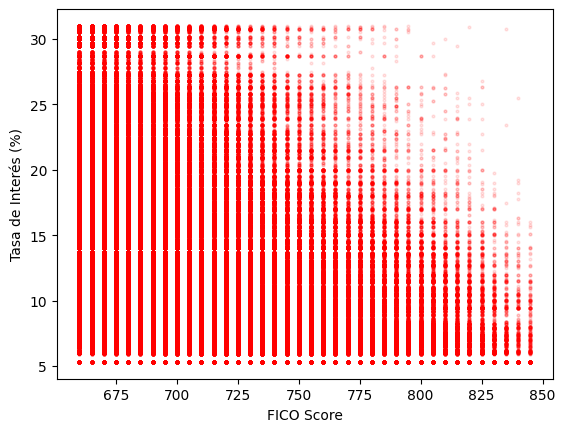

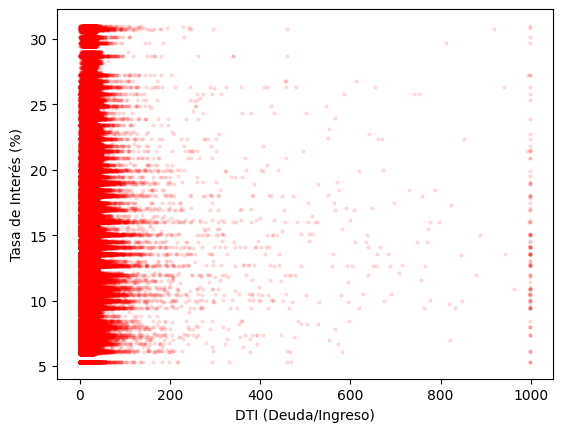

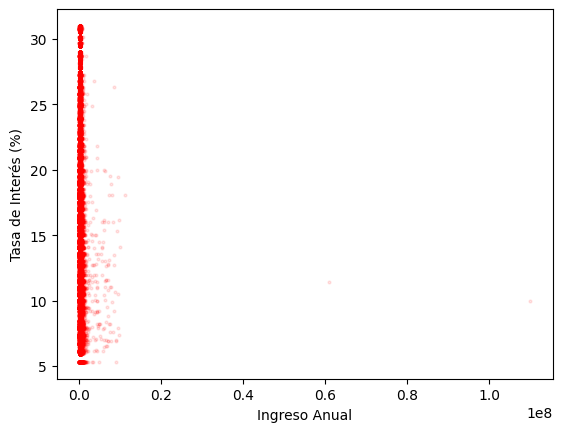

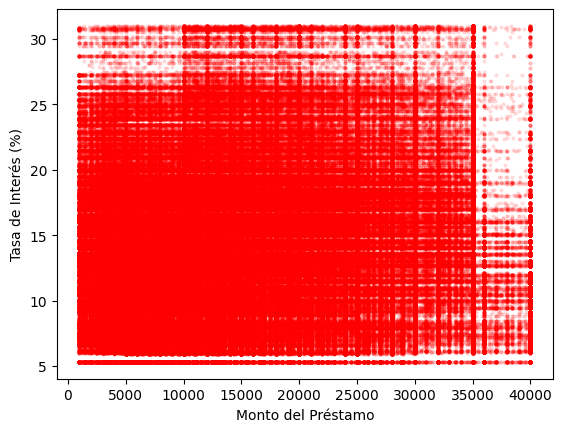

In [12]:
def graficarDatos(x, y, xlabel, ylabel):
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=2, alpha=0.1)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)

idx_fico = columnas_x.index('fico_range_low')
idx_dti  = columnas_x.index('dti')
idx_inc  = columnas_x.index('annual_inc')
idx_loan = columnas_x.index('loan_amnt')

# Graficamos sobre los datos de ENTRENAMIENTO
graficarDatos(X_train[:, idx_fico], y_train, 'FICO Score',          'Tasa de Interés (%)')
graficarDatos(X_train[:, idx_dti],  y_train, 'DTI (Deuda/Ingreso)', 'Tasa de Interés (%)')
graficarDatos(X_train[:, idx_inc],  y_train, 'Ingreso Anual',       'Tasa de Interés (%)')
graficarDatos(X_train[:, idx_loan], y_train, 'Monto del Préstamo',  'Tasa de Interés (%)')

## Preparación de la matriz para entrenamiento

Se añade una **columna de unos** al inicio de $X$ para representar el término de intersección ($\theta_0$). Se preparan **ambos** conjuntos:

$$X_{\text{ready}} = \begin{bmatrix} 1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_{51}^{(1)} \\ 1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_{51}^{(2)} \\ \vdots & & & & \vdots \end{bmatrix}$$

Esto permite expresar la hipótesis como: $h_\theta(x) = X \cdot \theta$, donde $\theta$ tiene 52 elementos ($\theta_0$ + 51 coeficientes).

In [13]:
# Añadimos la columna de unos (término de intersección x0) a AMBOS conjuntos
X_train_ready = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_ready  = np.concatenate([np.ones((m_test, 1)),  X_test_norm],  axis=1)

print("Forma de X_train_ready:", X_train_ready.shape)
print("Forma de X_test_ready: ", X_test_ready.shape)

# Vistazo rápido al primer cliente de entrenamiento
print("\nPrimer cliente (train) listo para entrenar:")
print(X_train_ready[:5, :5], "...")

Forma de X_train_ready: (1729892, 52)
Forma de X_test_ready:  (432473, 52)

Primer cliente (train) listo para entrenar:
[[ 1.         -0.86687254 -0.63936375 -0.35697498 -0.9855976 ]
 [ 1.         -0.56279809 -0.63936375 -0.35697498 -0.9855976 ]
 [ 1.         -0.01980799 -0.63936375 -0.35697498 -0.9855976 ]
 [ 1.          0.74037814  1.5640549  -0.35697498  1.01461286]
 [ 1.          0.08879002 -0.63936375 -0.35697498 -0.9855976 ]] ...


## Función de costo (Cost Function)

La función de costo mide qué tan lejos están las predicciones del modelo de los valores reales. Para regresión lineal usamos el **Error Cuadrático Medio (MSE)** dividido por 2:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Donde:
- $h_\theta(x^{(i)}) = X^{(i)} \cdot \theta$ → predicción del modelo para el ejemplo $i$.
- $y^{(i)}$ → tasa de interés real del ejemplo $i$.
- $m$ → número de ejemplos de entrenamiento.

El factor $\frac{1}{2}$ simplifica la derivada durante el gradiente descendente.

In [14]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


## Descenso por el Gradiente (Gradient Descent)

Algoritmo iterativo que ajusta los pesos $\theta$ para minimizar $J(\theta)$:

$$\theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

En forma vectorizada (como está implementado):

$$\theta := \theta - \frac{\alpha}{m} \cdot (X\theta - y)^T \cdot X$$

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| $\alpha$ (learning rate) | 0.01 | Tamaño del paso en cada iteración |
| `num_iters` | 1000 | Número de iteraciones |

- **$\alpha$ muy grande** → el costo oscila o diverge.
- **$\alpha$ muy pequeño** → converge muy lentamente.
- Se verifica convergencia observando que $J(\theta)$ **decrece** en cada iteración.

In [15]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### Costo inicial y entrenamiento

Con $\theta = \vec{0}$, el costo inicial es alto porque el modelo predice 0% para todos.  

In [16]:
theta_inicial = np.zeros(X_train_ready.shape[1])
Costo_inicial = computeCostMulti(X_train_ready, y_train, theta_inicial)

print(f"El vector theta inicial tiene {len(theta_inicial)} elementos (todos en cero).")
print(f"Con estos thetas iniciales, el modelo tiene un costo (error) de: {Costo_inicial:.2f}")

El vector theta inicial tiene 52 elementos (todos en cero).
Con estos thetas iniciales, el modelo tiene un costo (error) de: 97.42


### Gráfica de convergencia

La gráfica muestra $J(\theta)$ vs. número de iteraciones:
- **Curva descendente suave** → el modelo está aprendiendo correctamente.
- **Aplanamiento** → el modelo ha convergido (ya no mejora significativamente).
- Si la curva **sube**, el $\alpha$ es demasiado grande.

Con $\alpha = 0.01$ y 1000 iteraciones la curva se aplana completamente, confirmando convergencia.

También se realiza una predicción de prueba sobre un ejemplo **del conjunto de test** — un dato que el modelo nunca vio durante el entrenamiento.

Primeros 5 valores de theta calculados:  [13.08818244  0.24499506  1.751439    0.03586536 -0.20774357]
PREDICCIÓN DE PRUEBA (dato de TEST):
Tasa de interés predecida por el modelo: 18.12%
Tasa de interés REAL que le dio el banco: 13.59%


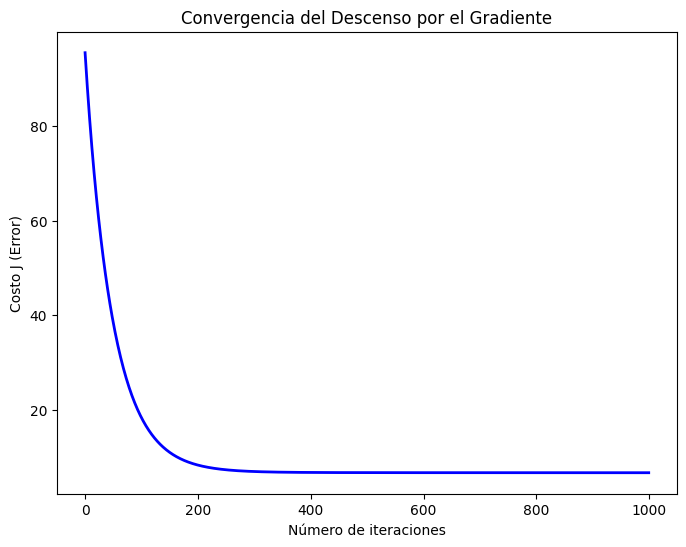

In [17]:
alpha = 0.01 
num_iters = 1000

# Inicializa theta con ceros y ejecuta el descenso por el gradiente SOLO sobre TRAIN
theta = np.zeros(X_train_ready.shape[1])
theta, J_history = gradientDescentMulti(X_train_ready, y_train, theta, alpha, num_iters)

# GRÁFICA DE CONVERGENCIA
pyplot.figure(figsize=(8, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Convergencia del Descenso por el Gradiente')

print('Primeros 5 valores de theta calculados: ', theta[:5])

# PREDICCIÓN DE PRUEBA sobre un ejemplo de TEST
X_prueba = X_test_ready[0]
tasa_predicha = np.dot(X_prueba, theta)   


print('PREDICCIÓN DE PRUEBA (dato de TEST):')

print(f'Tasa de interés predecida por el modelo: {tasa_predicha:.2f}%')
print(f'Tasa de interés REAL que le dio el banco: {y_test[0]:.2f}%')

## Ecuación Normal (Normal Equation)

Solución analítica (cerrada) que calcula los $\theta$ óptimos en un solo paso, **sin iteraciones ni normalización**:

$$\theta = (X^T X)^{-1} X^T y$$

| Ventaja | Desventaja |
|---|---|
| No requiere elegir $\alpha$ | Lenta para $n$ grande: inversión es $O(n^3)$ |
| No requiere normalización | Puede fallar si $X^T X$ es singular (multicolinealidad) |
| Solución exacta en un paso | No escala bien a millones de features |


In [18]:
def normalEqn(X, y):
    # theta = (X^T * X)^-1 * X^T * y
    # Usamos pinv (pseudoinversa) en lugar de inv para mayor estabilidad numérica
    # Si la matriz X^T*X es singular (por multicolinealidad), inv falla pero pinv no
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

In [19]:
# La ecuación normal no necesita normalización, usa los datos ORIGINALES de TRAIN
X_train_con_unos = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
theta_normal = normalEqn(X_train_con_unos, y_train)
print("Theta calculado por Ecuación de la Normal (primeros 5):")
print(theta_normal[:5])

Theta calculado por Ecuación de la Normal (primeros 5):
[ 2.87175449e+01  2.93294107e-05  1.60151518e-01  1.09937657e-01
 -4.05627166e-01]


### Comparación de métodos

Se predice la tasa de interés de un **mismo cliente de test** con ambos métodos.  
Si el gradiente descendente convergió correctamente, ambas predicciones deberían ser muy parecidas.  
Diferencias grandes indicarían que el gradiente necesita más iteraciones.

In [20]:
# Comparación sobre un dato de TEST 
datos_cliente = X_test[0, :] 

# 1. PREDICCIÓN CON GRADIENTE (Usa X normalizada y thetas del gradiente)
X_grad = np.append([1], (datos_cliente - mu) / sigma)
pred_grad = np.dot(X_grad, theta)

# 2. PREDICCIÓN CON ECUACIÓN NORMAL (Usa X original y thetas de la normal)
X_norm_eqn = np.append([1], datos_cliente)
pred_norm = np.dot(X_norm_eqn, theta_normal)

print(f"Predicción Gradiente:  {pred_grad:.2f}%")
print(f"Predicción Ec. Normal: {pred_norm:.2f}%")
print(f"Valor Real (TEST):     {y_test[0]:.2f}%")

Predicción Gradiente:  18.12%
Predicción Ec. Normal: 18.08%
Valor Real (TEST):     13.59%


In [21]:
# Comparación sobre un dato de TEST (que el modelo nunca vio)
datos_cliente = X_test[0, :] 

# 1. PREDICCIÓN CON GRADIENTE (Usa X normalizada y thetas del gradiente)
X_grad = np.append([1], (datos_cliente - mu) / sigma)
pred_grad = np.dot(X_grad, theta)

# 2. PREDICCIÓN CON ECUACIÓN NORMAL (Usa X original y thetas de la normal)
X_norm_eqn = np.append([1], datos_cliente)
pred_norm = np.dot(X_norm_eqn, theta_normal)

print(f"Predicción Gradiente:  {pred_grad:.2f}%")
print(f"Predicción Ec. Normal: {pred_norm:.2f}%")
print(f"Valor Real (TEST):     {y_test[0]:.2f}%")

Predicción Gradiente:  18.12%
Predicción Ec. Normal: 18.08%
Valor Real (TEST):     13.59%


## Predicción para un cliente nuevo

Se construye un vector con 51 valores que representan un **cliente hipotético** y se predice su tasa de interés.

**Proceso:**
1. Se crea el vector con datos crudos del cliente (51 features, sin las eliminadas por multicolinealidad).
2. Se normaliza usando **la misma** $\mu$ y $\sigma$ del entrenamiento (fundamental — nunca recalcular con datos nuevos).
3. Se agrega el 1 de la intersección.
4. Se calcula $\hat{y} = X_{\text{nuevo}} \cdot \theta$.

In [22]:
# Para predecir se normaliza con la misma mu y sigma del entrenamiento
# Ejemplo: préstamo de 10000, 36 meses, fico=720, dti=15, annual_inc=60000
# Vector de 51 features (sin fico_range_high, avg_cur_bal, num_sats)
x_nuevo = np.array([10000, 36, 0, 1, 0, 1, 60000, 15,
                    720, 0, 1, 8, 20, 0, 5000,
                    45, 80000, 25000, 15000, 12000,
                    8000, 20000, 50, 85, 30, 0, 3, 0,
                    0, 0, 0, 0, 120, 5, 3, 12, 2, 1,
                    3, 0, 0, 0, 0, 3, 4, 5,
                    6, 9, 12, 8, 10])

print(f'Vector del cliente tiene {len(x_nuevo)} features (esperado: {len(columnas_x)})')

# Normalizar con mu y sigma del entrenamiento
xp = (x_nuevo - mu) / sigma
xp = np.concatenate([[1], xp])  # agregar el 1 para theta_0

y_pred = np.dot(xp, theta)
print(f'Tasa de interés predicha: {y_pred:.2f}%')

Vector del cliente tiene 51 features (esperado: 51)
Tasa de interés predicha: 12.57%


## Evaluación del modelo — Predicciones sobre datos de TEST

Se muestran las predicciones vs. valores reales para los primeros 100 préstamos **del conjunto de test** — datos que el modelo **nunca vio** durante el entrenamiento.

La columna "Error" muestra la diferencia absoluta: $|y_{\text{real}} - y_{\text{pred}}|$.

In [23]:
# 100 predicciones sobre datos de TEST (que el modelo NUNCA vio durante entrenamiento)
X_100      = X_test_ready[:100]
y_100_real = y_test[:100]
y_100_pred = np.dot(X_100, theta)

print(f"{'#':<5} {'Real':>10} {'Predicho':>10} {'Error':>10}")
print('-' * 38)
for i in range(100):
    error = abs(y_100_real[i] - y_100_pred[i])
    print(f"{i+1:<5} {y_100_real[i]:>10.2f} {y_100_pred[i]:>10.2f} {error:>10.2f}")

#           Real   Predicho      Error
--------------------------------------
1          13.59      18.12       4.53
2           6.67      11.33       4.66
3           9.16       8.74       0.42
4           7.89      11.56       3.67
5          15.31      12.90       2.41
6          14.99      12.47       2.52
7           9.93      14.62       4.69
8           8.67       9.83       1.16
9          12.99      15.22       2.23
10          9.93       9.92       0.01
11         15.59      16.72       1.13
12         11.44       9.31       2.13
13         20.20      16.33       3.87
14         11.99      13.70       1.71
15          6.11       8.24       2.13
16         16.02      13.72       2.30
17         17.09      12.08       5.01
18         11.99      13.42       1.43
19         20.39      10.40       9.99
20         10.91      12.07       1.16
21         20.89      14.24       6.65
22          7.34      10.39       3.05
23         11.06      13.95       2.89
24         16.55      13.

## Métricas de error (sobre TODO el conjunto de Test)

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MSE** | $\frac{1}{m}\sum(y_i - \hat{y}_i)^2$ | Error cuadrático promedio. Penaliza errores grandes cuadráticamente. |
| **RMSE** | $\sqrt{MSE}$ | En la misma unidad que $y$ (%). "El modelo se equivoca ~X% en promedio." |
| **MAE** | $\frac{1}{m}\sum\|y_i - \hat{y}_i\|$ | Error absoluto promedio. Más robusto ante outliers que MSE. |
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | **Proporción de varianza explicada.** R²=1.0 → perfecto. R²=0 → no mejor que predecir la media. |

> **R² es la métrica estándar** para evaluar regresiones. Responde la pregunta: *"¿Qué porcentaje de la variabilidad de la tasa de interés logra explicar mi modelo?"*

In [24]:
# Métricas sobre TODO el conjunto de TEST (no solo 100)
y_test_pred = np.dot(X_test_ready, theta)

mse  = np.mean((y_test - y_test_pred) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test - y_test_pred))

# R² — Coeficiente de determinación
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot

print('='*50)
print('MÉTRICAS DE EVALUACIÓN (sobre datos de TEST)')
print('='*50)
print(f'MSE  (Error Cuadrático Medio):      {mse:.4f}')
print(f'RMSE (Raíz Error Cuadrático Medio): {rmse:.4f}')
print(f'MAE  (Error Absoluto Medio):        {mae:.4f}')
print(f'R²   (Coeficiente de Determinación): {r2:.4f}')
print(f'\nInterpretación:')
print(f'  → El modelo explica el {r2*100:.1f}% de la varianza de la tasa de interés.')
print(f'  → Se equivoca en promedio {rmse:.2f}% en la tasa de interés.')
print(f'  → Total de ejemplos evaluados: {m_test}')

MÉTRICAS DE EVALUACIÓN (sobre datos de TEST)
MSE  (Error Cuadrático Medio):      13.3746
RMSE (Raíz Error Cuadrático Medio): 3.6571
MAE  (Error Absoluto Medio):        2.7810
R²   (Coeficiente de Determinación): 0.4306

Interpretación:
  → El modelo explica el 43.1% de la varianza de la tasa de interés.
  → Se equivoca en promedio 3.66% en la tasa de interés.
  → Total de ejemplos evaluados: 432473


### Gráfica: Tasa Real vs Predicha (datos de TEST)

Esta gráfica superpone la tasa real (azul) y la predicha (rojo) para 100 préstamos **del conjunto de test**:
- **Líneas cercanas** → buena predicción para ese préstamo.
- **Grandes separaciones** → el modelo falla en esos casos (posiblemente clientes atípicos).
- Que ambas líneas sigan un patrón similar confirma que el modelo **generaliza** bien a datos no vistos.

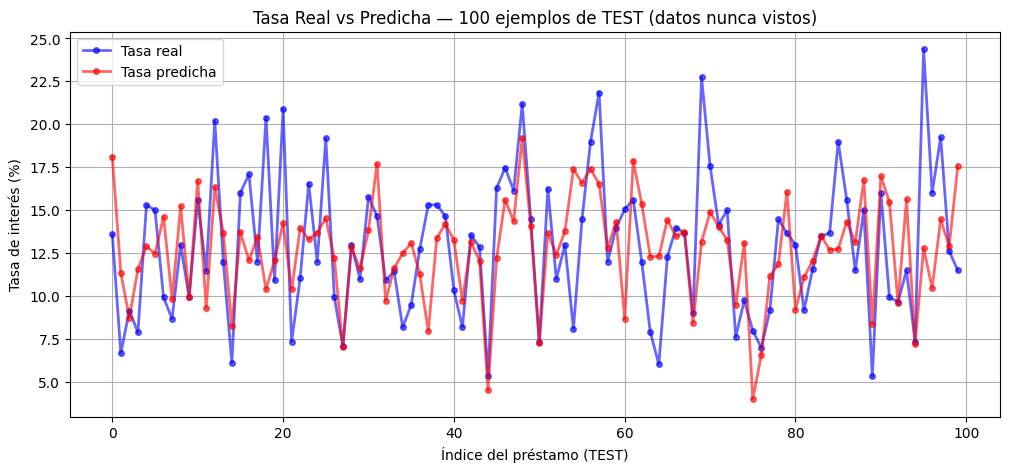

In [25]:
# Gráfica real vs predicho sobre datos de TEST
pyplot.figure(figsize=(12, 5))
pyplot.plot(np.arange(100), y_test[:100], 'bo-', label='Tasa real',     alpha=0.6, ms=4, lw=2)
pyplot.plot(np.arange(100), y_test_pred[:100], 'ro-', label='Tasa predicha', alpha=0.6, ms=4, lw=2)
pyplot.xlabel('Índice del préstamo (TEST)')
pyplot.ylabel('Tasa de interés (%)')
pyplot.title('Tasa Real vs Predicha — 100 ejemplos de TEST (datos nunca vistos)')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

GRADIO

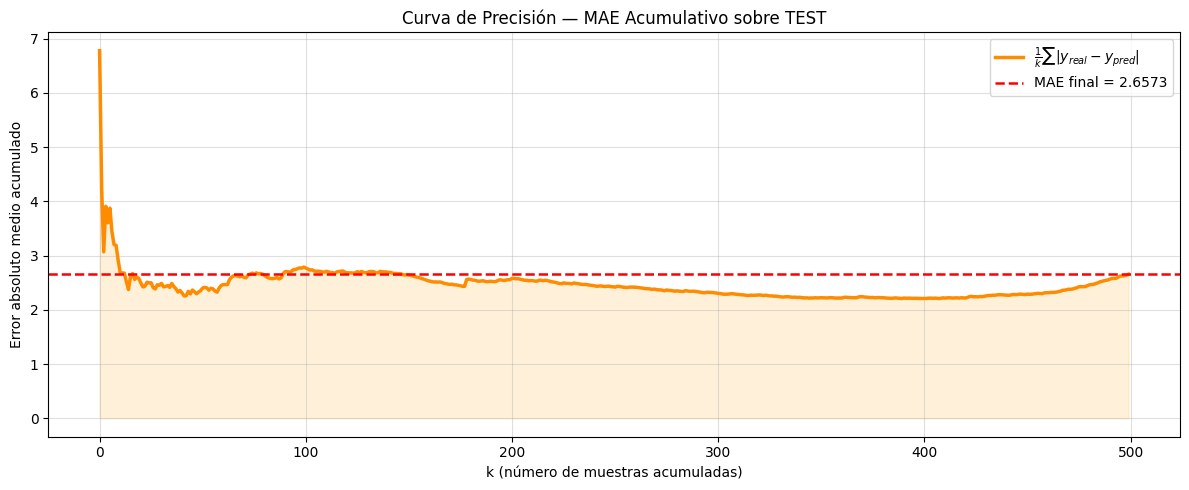

MAE final (todas las muestras): 2.6573


In [29]:
# CURVA DE PRECISION
N = 500

y_real = y_test[:N]
y_pred = y_test_pred[:N]


orden      = np.argsort(y_real)
y_real_ord = y_real[orden]
y_pred_ord = y_pred[orden]


errores_abs   = np.abs(y_real_ord - y_pred_ord)        
error_acum    = np.cumsum(errores_abs) / np.arange(1, N+1) 

pyplot.figure(figsize=(12, 5))
pyplot.plot(np.arange(N), error_acum, color='darkorange', lw=2.5, label=r'$\frac{1}{k}\sum|y_{real}-y_{pred}|$')
pyplot.axhline(y=error_acum[-1], color='red', linestyle='--', lw=1.8,
               label=f'MAE final = {error_acum[-1]:.4f}')
pyplot.fill_between(np.arange(N), error_acum, alpha=0.15, color='orange')
pyplot.xlabel('k (número de muestras acumuladas)')
pyplot.ylabel('Error absoluto medio acumulado')
pyplot.title('Curva de Precisión — MAE Acumulativo sobre TEST')
pyplot.legend()
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print(f'MAE final (todas las muestras): {error_acum[-1]:.4f}')

In [26]:
# Instalamos la librería para crear la interfaz web
!pip install -q gradio

In [ ]:

def predecir_interes_interactivo(monto, plazo, ingresos, fico, dti, hipoteca, verificado, historial):
    # 1. Copiamos el vector de medias globales para las variables no presentes en el UI
    x_input = mu.copy() 

    # 2. Mapeo de variables de la interfaz a los índices de la matriz X
    # Usamos .index() para asegurar que caigan en la posición exacta de tus 51 columnas
    x_input[columnas_x.index('loan_amnt')] = monto
    x_input[columnas_x.index('term')] = plazo
    x_input[columnas_x.index('annual_inc')] = ingresos
    x_input[columnas_x.index('fico_range_low')] = fico
    x_input[columnas_x.index('dti')] = dti
    
    # Lógica para variables One-Hot Encoding
    x_input[columnas_x.index('home_ownership_MORTGAGE')] = 1 if hipoteca == "SÍ" else 0
    x_input[columnas_x.index('verification_status_Verified')] = 1 if verificado == "SÍ" else 0
    x_input[columnas_x.index('credit_history_years')] = historial

    # 3. Normalización: Aplicamos la misma escala que usamos en el entrenamiento
    x_norm = (x_input - mu) / sigma
    
    # 4. Concatenamos el bias (x0 = 1) para que coincida con la dimensión de theta
    x_ready = np.concatenate([[1], x_norm])
    
    # 5. Predicción mediante Producto Punto: y_hat = X * theta
    prediccion = np.dot(x_ready, theta)
    
    # Devolvemos solo el número con formato profesional
    return f"{prediccion:.2f}%"

In [ ]:
import gradio as gr

# Definición de perfiles predeterminados para pruebas rápidas
# Orden: [Monto, Plazo, Ingresos, FICO, DTI, Hipoteca, Verificado, Historial]
perfiles_bancarios = [
    [5000, 36, 25000, 640, 30.5, "NO", "NO", 2],   # Perfil: Riesgo / Recién iniciado
    [15000, 36, 45000, 710, 15.0, "NO", "SÍ", 7],  # Perfil: Estándar estable
    [25000, 60, 65000, 690, 22.0, "SÍ", "SÍ", 12], # Perfil: Consolidación de deuda
    [35000, 36, 110000, 780, 8.0, "SÍ", "SÍ", 18], # Perfil: Cliente Preferencial
    [12000, 36, 95000, 820, 4.5, "SÍ", "SÍ", 25]   # Perfil: Excelente / Bajo Riesgo
]

demo = gr.Interface(
    fn=predecir_interes_interactivo,
    inputs=[
        gr.Slider(1000, 40000, step=500, label="Monto del prestamo (USD)", value=10000),
        gr.Radio([36, 60], label="Plazo del prestamo (Meses)", value=36),
        gr.Number(label="Ingresos anuales brutos (USD)", value=50000),
        gr.Slider(600, 850, step=1, label="Calificacion FICO", value=700),
        gr.Slider(0, 50, step=0.1, label="Relacion Deuda/Ingresos (DTI %)", value=15),
        gr.Dropdown(["SÍ", "NO"], label="Posee hipoteca activa", value="NO"),
        gr.Dropdown(["SÍ", "NO"], label="Ingresos verificados", value="SÍ"),
        gr.Slider(1, 40, step=1, label="Años de historial crediticio", value=10)
    ],
    outputs=gr.Textbox(label="Tasa de interes anual estimada"),
    examples=perfiles_bancarios,
    title="Simulador de Riesgo Crediticio - USFX Systems Engineering",
    description="Analisis de tasas de interes mediante Regresion Lineal Multiple. Seleccione un perfil predeterminado o ajuste los valores manualmente.",
    theme="soft",
    flagging_mode ="never"
)

# El link de share=True te servirá para mostrarle el proyecto a tus docentes o amigos
demo.launch(share=True)

In [ ]:

# Guardamos los resultados en el directorio de trabajo de Kaggle
np.save('theta_model.npy', theta)
np.save('mu_model.npy', mu)
np.save('sigma_model.npy', sigma)

print("Archivos guardados en /kaggle/working. Los verás en la pestaña 'Output' a la derecha.")